In [1]:
%store -r combined_df outside_hayman_bounds hayman_bounds_gdf bbox_gdf

In [11]:
# Imports
import geopandas as gpd
import pandas as pd
import hvplot.pandas
import os
import pathlib
import xarray as xr
from glob import glob
import rioxarray as rxr
import matplotlib.pyplot as plt
from shapely.geometry import mapping, box
import datetime
from scipy.stats import shapiro, pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
BASE_DATA_PATH = pathlib.Path.cwd().parent / "data"
BASE_NDVI_PATH = BASE_DATA_PATH / "NDVI"
BASE_TEMP_PATH = BASE_DATA_PATH / "Temperature"

In [4]:
combined_df

,inner_temp,outer_temp,data_count,diff_temps,inner_NDVI,outer_NDVI,diff_ndvis
year,,,,,,,
2001.0,303.969465,302.605033,10.0,1.364432,0.575758,0.563070,0.012688
2002.0,315.397217,309.096171,17.0,6.301047,0.287545,0.476006,-0.188461
2003.0,313.969845,308.514145,17.0,5.455700,0.317190,0.519118,-0.201928
2004.0,303.818255,300.497750,19.0,3.320505,0.371030,0.523545,-0.152516
2005.0,311.091337,306.569503,15.0,4.521835,0.373056,0.547559,-0.174502
2006.0,305.625640,302.594453,17.0,3.031187,0.353584,0.507795,-0.154212
2007.0,306.005837,302.326041,18.0,3.679796,0.408413,0.541945,-0.133532
2008.0,311.256641,305.865070,19.0,5.391571,0.337373,0.513005,-0.175633
2009.0,304.954379,301.513397,16.0,3.440981,0.413318,0.556825,-0.143507


In [5]:
dropped_first_year = combined_df.drop(2001)
dropped_first_year

,inner_temp,outer_temp,data_count,diff_temps,inner_NDVI,outer_NDVI,diff_ndvis
year,,,,,,,
2002.0,315.397217,309.096171,17.0,6.301047,0.287545,0.476006,-0.188461
2003.0,313.969845,308.514145,17.0,5.455700,0.317190,0.519118,-0.201928
2004.0,303.818255,300.497750,19.0,3.320505,0.371030,0.523545,-0.152516
2005.0,311.091337,306.569503,15.0,4.521835,0.373056,0.547559,-0.174502
2006.0,305.625640,302.594453,17.0,3.031187,0.353584,0.507795,-0.154212
2007.0,306.005837,302.326041,18.0,3.679796,0.408413,0.541945,-0.133532
2008.0,311.256641,305.865070,19.0,5.391571,0.337373,0.513005,-0.175633
2009.0,304.954379,301.513397,16.0,3.440981,0.413318,0.556825,-0.143507
2010.0,309.427356,304.574391,11.0,4.852965,0.388620,0.550164,-0.161543


In [6]:
# Normality tests
print('NDVIs: ',shapiro(dropped_first_year.diff_ndvis)) # Normal
print('Temps:' , shapiro(dropped_first_year.diff_temps)) # 

NDVIs:  ShapiroResult(statistic=np.float64(0.956091238848152), pvalue=np.float64(0.36502091118338154))
Temps: ShapiroResult(statistic=np.float64(0.9792818225484937), pvalue=np.float64(0.882268547400935))


<Axes: xlabel='diff_ndvis', ylabel='diff_temps'>

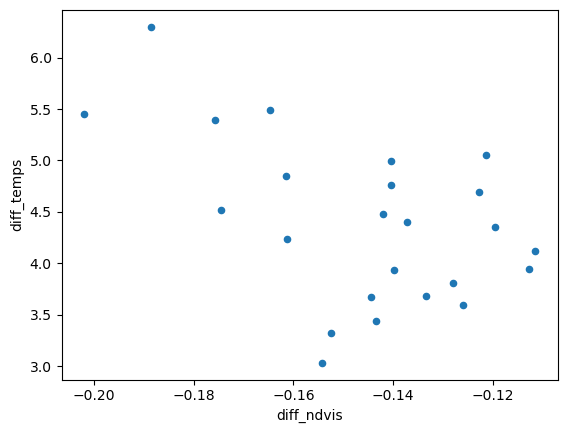

In [7]:
dropped_first_year.plot.scatter(x="diff_ndvis", y="diff_temps")

In [24]:
y = dropped_first_year.diff_temps.values
x = dropped_first_year.diff_ndvis.values

x = x.reshape(len(x),1)
y = y.reshape(len(y),1)

lm_dropped = LinearRegression().fit(x,y)
corr_test = pearsonr(dropped_first_year.diff_ndvis, dropped_first_year.diff_temps) # Statistically significant, but not fully to be trusted

In [28]:
corr_test.statistic

np.float64(-0.5055135895031564)

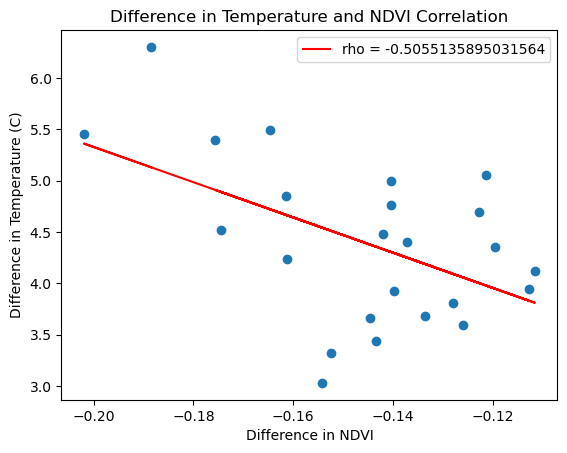

In [35]:
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, lm_dropped.predict(x), color='red', label=f'rho = {corr_test.statistic}')
ax.set(xlabel='Difference in NDVI',ylabel='Difference in Temperature (C)', title='Difference in Temperature and NDVI Correlation')
#ax.ylabel('Difference in Temperature (C)')
#ax.set_label(f'rho = {corr_test.statistic}')
ax.legend()
plt.show()

PearsonRResult(statistic=np.float64(-0.5055135895031564), pvalue=np.float64(0.011738025209481563))

In [13]:
hayman_bounds_gdf.hvplot(geo=True, tiles=True,
                         frame_width=600,frame_height=600,
                         fill_alpha=0, line_color="red",
                        line_width=2)

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]

[Text(0, 0.5, 'Difference in Temperature (C)\n(Inside minus Outside)')]

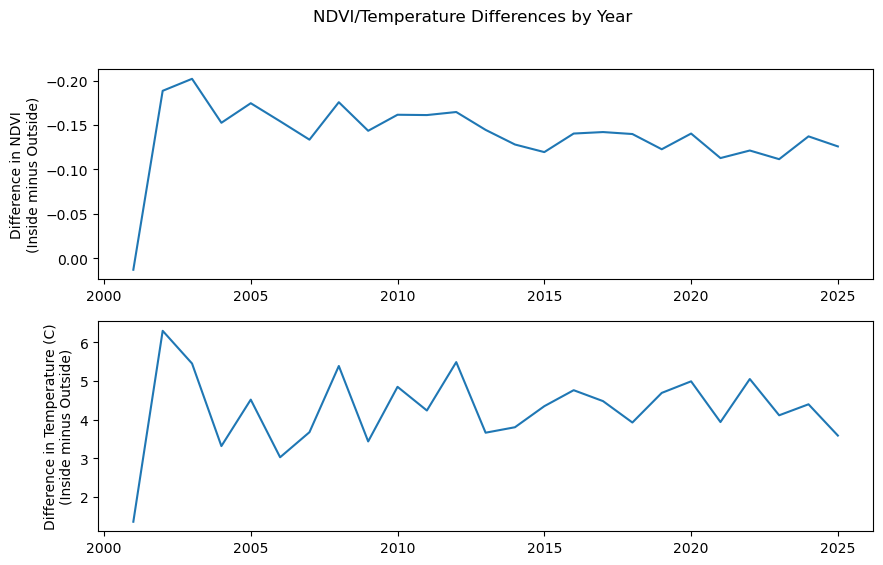

In [23]:
fig, ax = plt.subplots(2, figsize=(10,6))
fig.suptitle('NDVI/Temperature Differences by Year')
ax[0].invert_yaxis()
ax[0].plot(combined_df.diff_ndvis)
ax[0].set(ylabel='Difference in NDVI\n(Inside minus Outside)')
ax[1].plot(combined_df.diff_temps)
ax[1].set(ylabel='Difference in Temperature (C)\n(Inside minus Outside)')

In [14]:
# Visualizing the NDVI data
vis_ndvi_pre_fire = rxr.open_rasterio(BASE_NDVI_PATH / "MOD13Q1.A2001209.h09v05.061.2020064123714.hdf",
                                     masked=True).squeeze()


vis_ndvi_post_fire = rxr.open_rasterio(BASE_NDVI_PATH / "MOD13Q1.A2002209.h09v05.061.2020077124500.hdf",
                                      masked=True).squeeze()

vis_ndvi_pre_fire = vis_ndvi_pre_fire['250m 16 days NDVI'].rio.reproject(hayman_bounds_gdf.crs)
vis_ndvi_post_fire = vis_ndvi_post_fire['250m 16 days NDVI'].rio.reproject(hayman_bounds_gdf.crs)

vis_ndvi_pre_fire = vis_ndvi_pre_fire.rio.clip(bbox_gdf.geometry.apply(mapping),
                                               crs=hayman_bounds_gdf.crs,
                                               all_touched=False,
                                               from_disk=True)

vis_ndvi_post_fire = vis_ndvi_post_fire.rio.clip(bbox_gdf.geometry.apply(mapping),
                                               crs=hayman_bounds_gdf.crs,
                                               all_touched=False,
                                               from_disk=True)
vis_ndvi_pre_fire = vis_ndvi_pre_fire / vis_ndvi_pre_fire.scale_factor
vis_ndvi_post_fire = vis_ndvi_post_fire / vis_ndvi_post_fire.scale_factor

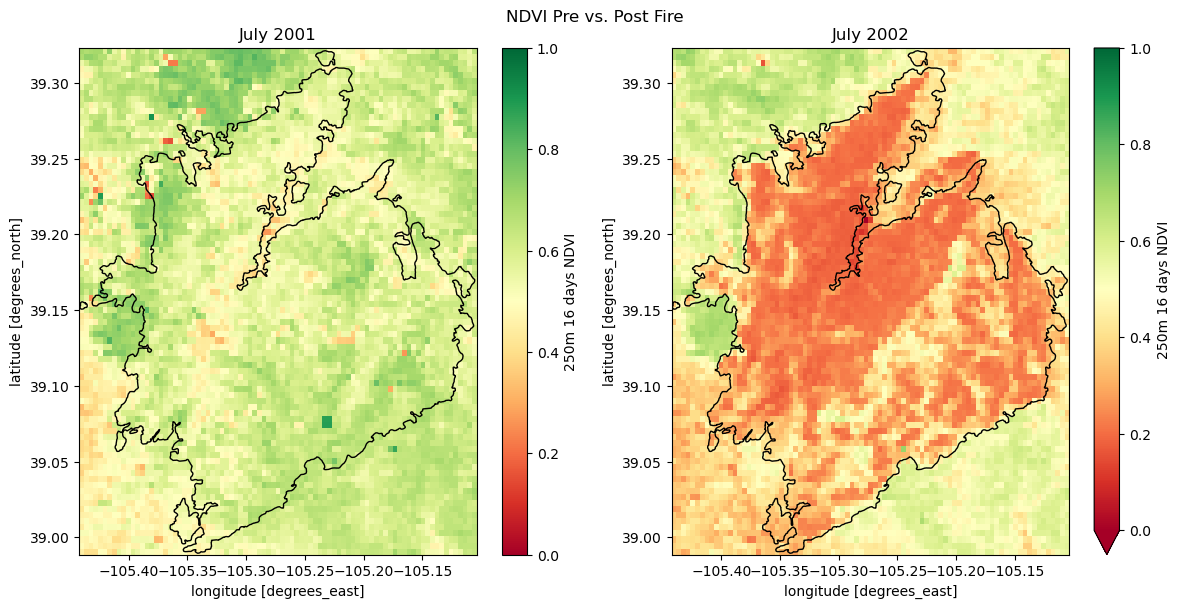

In [15]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
fig.suptitle('NDVI Pre vs. Post Fire')
vis_ndvi_pre_fire.plot(ax=axs[0], vmin=0, vmax=1, cmap="RdYlGn")
vis_ndvi_post_fire.plot(ax=axs[1], vmin=0, vmax=1, cmap="RdYlGn")
hayman_bounds_gdf.plot(ax=axs[0], facecolor="none")
hayman_bounds_gdf.plot(ax=axs[1], facecolor="none")
axs[0].set_title('July 2001')
axs[1].set_title('July 2002')


plt.tight_layout()

In [5]:
# Pre Fire File: MOD11A1.A2001186.h09v05.061.2020094181746.hdf
# Post Fire File: MOD11A1.A2002192.h09v05.061.2020128175551.hdf

surface_temp_pre_fire = rxr.open_rasterio(BASE_TEMP_PATH / "MOD11A1.A2001186.h09v05.061.2020094181746.hdf",
                                         masked=True).squeeze()
first_step_interp = surface_temp_pre_fire

surface_temp_pre_fire = surface_temp_pre_fire['LST_Day_1km'].interpolate_na(dim='x')
surface_temp_pre_fire = surface_temp_pre_fire.sortby('y')
surface_temp_pre_fire = surface_temp_pre_fire.interpolate_na(dim='y')
surface_temp_pre_fire = surface_temp_pre_fire.sortby('y', ascending=False)

second_step_interp = surface_temp_pre_fire

surface_temp_pre_fire = surface_temp_pre_fire.rio.reproject(hayman_bounds_gdf.crs)

surface_temp_pre_fire = surface_temp_pre_fire.rio.clip(bbox_gdf.geometry.apply(mapping),
                                                       crs=hayman_bounds_gdf.crs,
                                                       all_touched=False,
                                                       from_disk=True)

surface_temp_post_fire = rxr.open_rasterio(BASE_TEMP_PATH / "MOD11A1.A2002192.h09v05.061.2020128175551.hdf",
                                         masked=True).squeeze()

surface_temp_post_fire = surface_temp_post_fire['LST_Day_1km'].interpolate_na(dim='x')
surface_temp_post_fire = surface_temp_post_fire.sortby('y')
surface_temp_post_fire = surface_temp_post_fire.interpolate_na(dim='y')
surface_temp_post_fire = surface_temp_post_fire.sortby('y', ascending=False)

surface_temp_post_fire = surface_temp_post_fire.rio.reproject(hayman_bounds_gdf.crs)

third_step_interp = surface_temp_post_fire

surface_temp_post_fire = surface_temp_post_fire.rio.clip(bbox_gdf.geometry.apply(mapping),
                                                       crs=hayman_bounds_gdf.crs,
                                                       all_touched=False,
                                                       from_disk=True)

surface_temp_pre_fire = surface_temp_pre_fire * surface_temp_pre_fire.scale_factor
surface_temp_post_fire = surface_temp_post_fire * surface_temp_post_fire.scale_factor

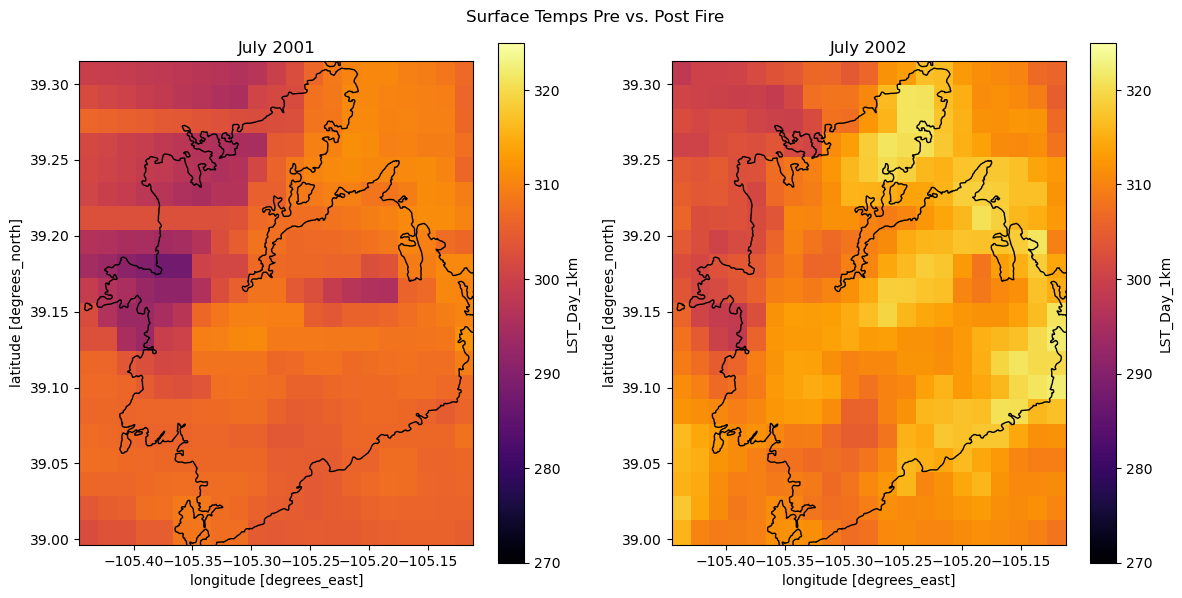

In [7]:
fig, axs = plt.subplots(1,2, figsize=(12,6))
fig.suptitle('Surface Temps Pre vs. Post Fire')
surface_temp_pre_fire.plot(ax=axs[0], vmin=270, vmax=325, cmap="inferno")
surface_temp_post_fire.plot(ax=axs[1], vmin=270, vmax=325, cmap="inferno")
hayman_bounds_gdf.plot(ax=axs[0], facecolor="none")
hayman_bounds_gdf.plot(ax=axs[1], facecolor="none")
axs[0].set_title('July 2001')
axs[1].set_title('July 2002')


plt.tight_layout()

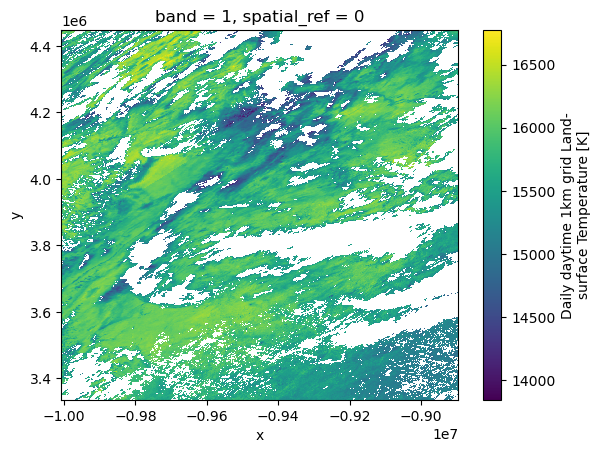

In [46]:
first_step_interp['LST_Day_1km'].plot()

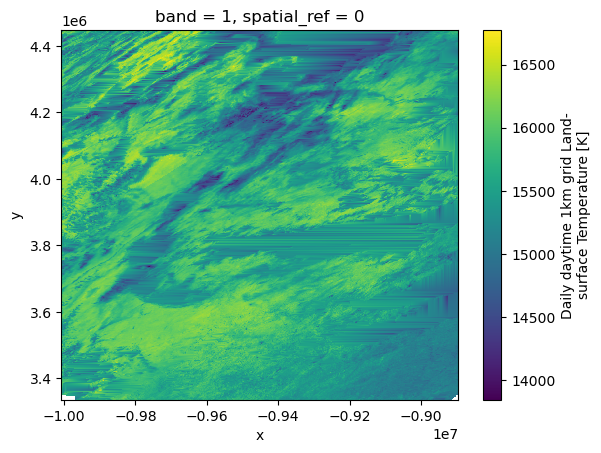

In [47]:
second_step_interp.plot()

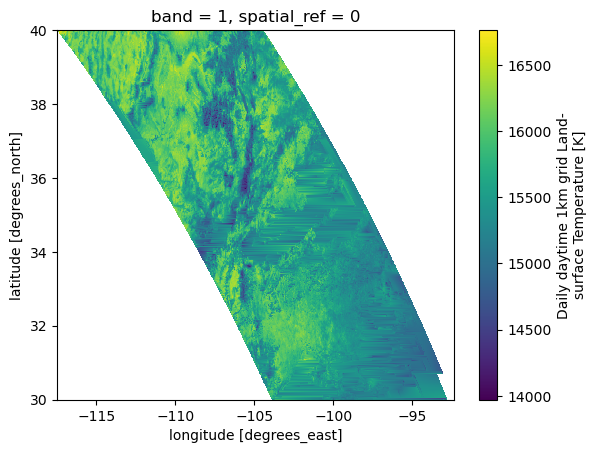

In [49]:
third_step_interp.plot()